# Spectrogram Separation

This notebook applies a regularized optimization-based spectrogram separation method
to a mixture spectrogram and compares the separated components against the known
reference spectrograms.

## Algorithm overview

Given a mixture spectrogram `Sz`, the algorithm finds `Sx` and `Sy` such that
`Sz ≈ Sx + Sy` by solving:

```
minimize  ‖Sz − Sx − Sy‖   +   α ‖B·Sx‖   +   β ‖Sy‖₁
```

where `B` is the first-order finite-difference matrix along the frequency axis.  
This encourages:
- **`Sx`** → spectrally smooth (tonal / harmonic content)
- **`Sy`** → sparse in time-frequency (transient / impulsive content)

## Important expectation

This is **blind structural decomposition** — the algorithm has no knowledge
of what the original sources sound like.  
Error metrics against the reference `R(x)` / `R(y)` will be large;
that is expected and does not indicate a bug.
The algorithm is useful when sources have structurally different time-frequency
patterns (e.g. sinusoidal + impulsive).

## 1. Setup

In [1]:
from pathlib import Path
import sys
import warnings
import numpy as np

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

In [2]:
from spectral_mixture_analysis.audio import load_mono_audio, match_length
from spectral_mixture_analysis.transforms import compute_representation, amplitude_to_db
from spectral_mixture_analysis.metrics import l2_error, relative_l2_error, mean_absolute_error
from spectral_mixture_analysis.separation import separate_spectrogram

## 2. Load signals and compute representations

We use a flute and bass track as the two known sources.
The STFT magnitude is used as the representation.
The same kwargs are applied consistently to every `compute_representation` call.

In [3]:
audio_path_x = PROJECT_ROOT / "data" / "samples" / "flute" / "Track1_flute.wav"
audio_path_y = PROJECT_ROOT / "data" / "samples" / "bass" / "Track10_Bass.wav"

x, sr = load_mono_audio(audio_path_x, sr=22050)
y, _  = load_mono_audio(audio_path_y, sr=22050)
x, y  = match_length(x, y, mode="truncate")

print(f"x : {len(x)} samples  ({len(x)/sr:.2f} s)  sr={sr}")
print(f"y : {len(y)} samples  ({len(y)/sr:.2f} s)")

x : 135559 samples  (6.15 s)  sr=22050
y : 135559 samples  (6.15 s)


In [4]:
# Transform parameters — applied to every compute_representation call
TRANSFORM  = "stft"
REP_KWARGS = dict(output="magnitude", n_fft=2048, hop_length=512)

rep_x   = compute_representation(x,   sr, transform_type=TRANSFORM, **REP_KWARGS)
rep_y   = compute_representation(y,   sr, transform_type=TRANSFORM, **REP_KWARGS)
rep_mix = compute_representation(x+y, sr, transform_type=TRANSFORM, **REP_KWARGS)

print(f"rep_x   shape: {rep_x.shape}  dtype: {rep_x.dtype}")
print(f"rep_y   shape: {rep_y.shape}  dtype: {rep_y.dtype}")
print(f"rep_mix shape: {rep_mix.shape}  dtype: {rep_mix.dtype}")

rep_x   shape: (1025, 265)  dtype: float32
rep_y   shape: (1025, 265)  dtype: float32
rep_mix shape: (1025, 265)  dtype: float32


## 3. Run spectrogram separation

Key hyperparameters:

| Parameter | Meaning | Typical range |
|---|---|---|
| `alpha` | Smoothness of Sx along frequency | 0.1 – 10 |
| `beta` | Sparsity of Sy (L1 penalty) | 1e-6 – 1e-3 |
| `gamma` | FISTA step size | 0.05 – 0.25 |
| `max_iter` | Outer alternating iterations | 100 – 500 |
| `tol` | Relative cost-decrease threshold | 1e-3 – 1e-4 |

In [5]:
separated = separate_spectrogram(
    rep_mix,
    n_sources=2,
    alpha=1.0,
    beta=1e-5,
    gamma=0.15,
    max_iter=300,
    tol=1e-3,
    n_inner_iter=10,
)

s0, s1 = separated

print(f"s0 shape: {s0.shape}  min={s0.min():.4f}  max={s0.max():.4f}")
print(f"s1 shape: {s1.shape}  min={s1.min():.4f}  max={s1.max():.4f}")
print(f"Reconstruction residual ||rep_mix - s0 - s1||: {np.linalg.norm(rep_mix - s0 - s1):.4f}")

s0 shape: (1025, 265)  min=0.0000  max=45.7138
s1 shape: (1025, 265)  min=-41.0467  max=343.7074
Reconstruction residual ||rep_mix - s0 - s1||: 0.0180


## 4. Source assignment

The algorithm does not know which separated component corresponds to which source.
We try both assignments and pick the one with the smaller total relative L2 error.

In [6]:
err_direct = relative_l2_error(s0, rep_x) + relative_l2_error(s1, rep_y)
err_swap   = relative_l2_error(s1, rep_x) + relative_l2_error(s0, rep_y)

if err_direct <= err_swap:
    sep_x, sep_y = s0, s1
    print(f"Assignment: s0 → x,  s1 → y  (total rel-L2: {err_direct:.4f} vs swapped: {err_swap:.4f})")
else:
    sep_x, sep_y = s1, s0
    print(f"Assignment: s1 → x,  s0 → y  (total rel-L2: {err_swap:.4f} vs direct: {err_direct:.4f})")

Assignment: s1 → x,  s0 → y  (total rel-L2: 2.3615 vs direct: 2.7198)


## 5. Metrics: separated components vs reference spectrograms

These errors will be substantially larger than in the linearity notebooks.  
Blind source separation is an ill-posed problem; the algorithm separates by
spectral structure (smooth vs sparse), not by matching known sources.

In [7]:
import pandas as pd

def compute_metrics(est: np.ndarray, ref: np.ndarray, label: str) -> dict:
    return {
        "comparison": label,
        "l2":          l2_error(est, ref),
        "relative_l2": relative_l2_error(est, ref),
        "mae":         mean_absolute_error(est, ref),
    }

rows = [
    compute_metrics(sep_x, rep_x, "sep_x  vs  rep_x"),
    compute_metrics(sep_y, rep_y, "sep_y  vs  rep_y"),
    compute_metrics(sep_x + sep_y, rep_mix, "sep_x+sep_y  vs  rep_mix"),
]

df_metrics = pd.DataFrame(rows).set_index("comparison")
df_metrics

,l2,relative_l2,mae
comparison,,,
sep_x vs rep_x,3641.858299,0.713304,1.247998
sep_y vs rep_y,3628.610112,1.648179,1.230366
sep_x+sep_y vs rep_mix,0.018020,0.000003,0.000012


In [8]:
# For context: how does the naive half-split (0.5 * rep_mix) compare?
naive = [
    compute_metrics(0.5 * rep_mix, rep_x, "0.5*rep_mix  vs  rep_x  (naive)"),
    compute_metrics(0.5 * rep_mix, rep_y, "0.5*rep_mix  vs  rep_y  (naive)"),
]
pd.DataFrame(naive).set_index("comparison")

,l2,relative_l2,mae
comparison,,,
0.5*rep_mix vs rep_x (naive),2820.605469,0.996059,0.590939
0.5*rep_mix vs rep_y (naive),2805.939697,0.990880,0.585751


## 6. Visualization

Three rows of plots:
1. Reference spectrograms `R(x)`, `R(y)`, `R(mix)` — ground truth
2. Separated components `sep_x`, `sep_y`, `sep_x + sep_y`
3. Difference maps vs reference

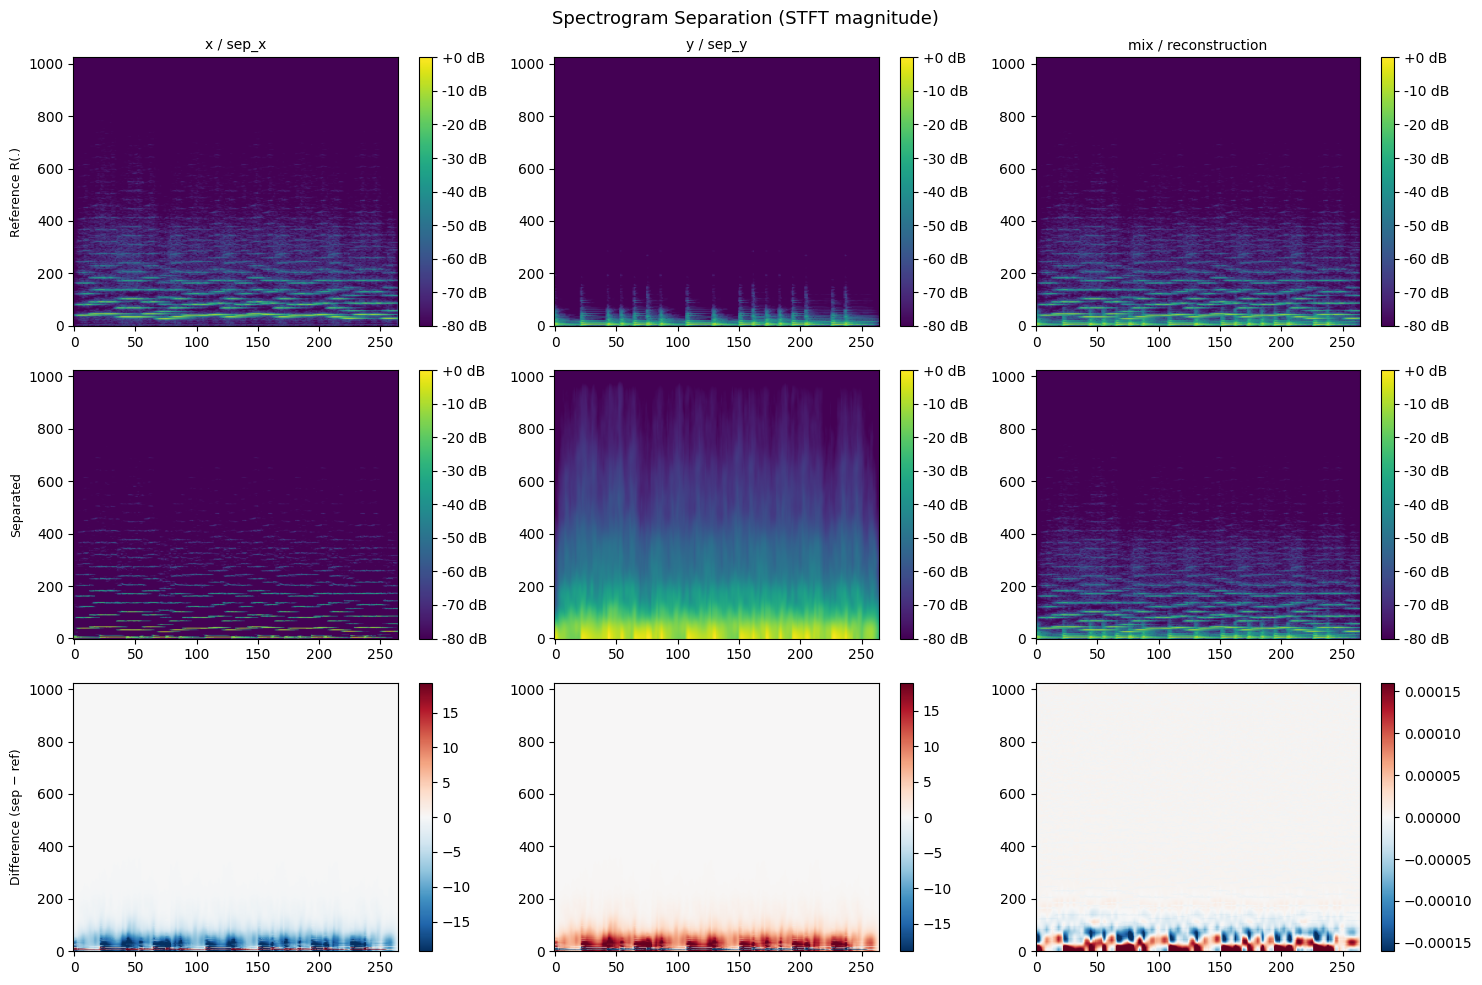

In [9]:
import matplotlib.pyplot as plt

def db(arr: np.ndarray) -> np.ndarray:
    """Safe amplitude-to-dB, clipping negatives before conversion."""
    return amplitude_to_db(np.clip(arr, 0, None))

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle("Spectrogram Separation (STFT magnitude)", fontsize=13)

col_titles = ["x / sep_x", "y / sep_y", "mix / reconstruction"]
row_titles = ["Reference R(.)", "Separated", "Difference (sep − ref)"]

refs      = [rep_x,  rep_y,  rep_mix]
separated_row = [sep_x, sep_y, sep_x + sep_y]

for col, (ref, sep) in enumerate(zip(refs, separated_row)):
    vmin = db(ref).min()
    vmax = db(ref).max()

    # Row 0: reference
    im = axes[0, col].imshow(db(ref), origin="lower", aspect="auto",
                              vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=axes[0, col], format="%+2.0f dB")

    # Row 1: separated
    im = axes[1, col].imshow(db(sep), origin="lower", aspect="auto",
                              vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=axes[1, col], format="%+2.0f dB")

    # Row 2: difference
    diff = sep - ref
    abs_max = np.percentile(np.abs(diff), 99)
    im = axes[2, col].imshow(diff, origin="lower", aspect="auto",
                              cmap="RdBu_r", vmin=-abs_max, vmax=abs_max)
    plt.colorbar(im, ax=axes[2, col])

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10)
for row, title in enumerate(row_titles):
    axes[row, 0].set_ylabel(title, fontsize=9)

plt.tight_layout()
plt.show()

## 7. Effect of hyperparameters

Quick sweep over `alpha` (smoothness) to show how it affects the decomposition.

In [10]:
alphas = [0.1, 1.0, 5.0, 10.0]

sweep_rows = []
for a in alphas:
    s0_a, s1_a = separate_spectrogram(rep_mix, alpha=a, beta=1e-5, max_iter=100)
    recon_err = relative_l2_error(s0_a + s1_a, rep_mix)
    sweep_rows.append({"alpha": a, "recon_relative_l2": recon_err,
                        "s0_sparsity": float(np.mean(s0_a == 0)),
                        "s1_sparsity": float(np.mean(s1_a == 0))})

pd.DataFrame(sweep_rows).set_index("alpha")

,recon_relative_l2,s0_sparsity,s1_sparsity
alpha,,,
0.1,0.000021,0.0,0.026931
1.0,0.000011,0.0,0.014465
5.0,0.000010,0.0,0.000909
10.0,0.000011,0.0,0.000681


## Summary

| | Value |
|---|---|
| Algorithm | Alternating optimization: closed-form Sx + FISTA Sy |
| Input | Any 2D non-negative spectrogram from `compute_representation()` |
| Output | `[Sx, Sy]` — smooth + sparse decomposition, same shape as input |
| Source assignment | Not automatic — compare against references to determine order |
| Expected error vs reference | Large (blind decomposition, no source priors) |
| Reconstruction error | Small (algorithm enforces `Sz ≈ Sx + Sy`) |